## 6 — MRdeeP Climate
Multivariate Multilevel Regression with Deep Generative Post-Stratification  

Pipeline:
1. `insert_data` — encodes survey + benchmark, builds augmented benchmark proportional to ACS population weights  
2. `fit` — trains an ensemble of CGANs (Wasserstein loss with gradient penalty)  
3. `post_stratify('state_fips')` — generates synthetic micro-data for every demographic cell, groups by state → `happening_bin` estimates extracted

In [21]:
# Install PyTorch (CPU) if needed — MRdeeP uses it as the deep-learning backend
%pip install torch --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Force PyTorch backend (mlx not installed in this env)
import os
os.environ["DEEPVERSE_BACKEND"] = "pytorch"

# Add the MRdeeP package to the path
sys.path.insert(0, "/Users/carmenk/Documents/CSS/Capstone/mrdeep/python")
from mrdeep import MRdeeP

DATA_DIR = "/Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/test_data/processed/"

### 1. Load and prepare data

In [23]:
survey_raw = pd.read_csv(DATA_DIR + "climate_survey_responses_recoded.csv",
                         dtype={"state_fips": str})
ps_frame   = pd.read_csv(DATA_DIR + "poststrat_state.csv",
                         dtype={"state_fips": str})

# ── Demographic variables shared between survey and benchmark ─────────────────
DEMOG_VARS = ["gender", "race4", "educ_category", "state_fips"]

OUTCOME_COLS = [c for c in survey_raw.columns if c.endswith("_bin")]
print(f"Survey raw:    {survey_raw.shape}")
print(f"Outcome cols:  {len(OUTCOME_COLS)} binary outcomes")
print(f"Poststrat:     {ps_frame.shape} | {ps_frame['state_fips'].nunique()} states")

Survey raw:    (1200, 42)
Outcome cols:  30 binary outcomes
Poststrat:     (1632, 9) | 51 states


In [24]:
# ── Survey: keep only rows with no NaN in any outcome, select cols ────────────
survey = (
    survey_raw[DEMOG_VARS + OUTCOME_COLS]
    .dropna()                          # drop any respondent with a DK in any outcome
    .copy()
)
survey["educ_category"] = survey["educ_category"].astype(str)

# ── Benchmark: add population-proportional count column ──────────────────────
# Normalize N_rounded so the augmented benchmark totals ~16,320 rows (10× strata)
# This preserves relative cell sizes so post_stratify() is population-weighted.
benchmark = ps_frame[DEMOG_VARS + ["N_rounded"]].copy()
benchmark["educ_category"] = benchmark["educ_category"].astype(str)
target_rows = len(benchmark) * 10          # ~16,320 total rows with oversample=1
benchmark["count"] = np.maximum(
    1,
    (benchmark["N_rounded"] / benchmark["N_rounded"].sum() * target_rows).round()
).astype(int)
benchmark = benchmark.drop(columns=["N_rounded"])

print(f"Survey (complete cases): {len(survey):,}  "
      f"({survey['happening_bin'].mean()*100:.1f}% believe GW is happening)")
print(f"Benchmark: {len(benchmark)} strata | count range [{benchmark['count'].min()}, {benchmark['count'].max()}]")
print(f"Augmented benchmark rows (oversample=1): {benchmark['count'].sum():,}")

Survey (complete cases): 26  (61.5% believe GW is happening)
Benchmark: 1632 strata | count range [1, 159]
Augmented benchmark rows (oversample=1): 16,559


### 2. Insert data into MRdeeP

In [25]:
mod = MRdeeP(ensembles=3, random_state=42)

mod.insert_data(
    survey    = survey,
    benchmark = benchmark,
    demog_vars = DEMOG_VARS,
    count_col  = "count",
    oversample = 1,     # augmented benchmark already sized; no further multiplication
)
print(mod)

MRdeeP (backend=pytorch, ensembles=3)
  Data inserted: True
  Survey: 26 obs, 30 substantive vars, 4 demographic vars
  Augmented benchmark: 16559 rows
  Fitted: False


### 3. Train CGAN ensemble
Default architecture: 4 × 256-neuron hidden layers, Wasserstein loss + gradient penalty.  
`patience=50` stops early if validation generator loss stops improving.

In [26]:
mod.fit(
    epochs       = 500,
    patience     = 50,
    batch_size   = 256,
    k            = 32,
    print_runtime = True,
)
print(mod)

Ensemble 1/3
Ensemble 2/3
Ensemble 3/3
Total fit time: 12.7 seconds.
MRdeeP (backend=pytorch, ensembles=3)
  Data inserted: True
  Survey: 26 obs, 30 substantive vars, 4 demographic vars
  Augmented benchmark: 16559 rows
  Fitted: True
    Noise dim (k): 32
    Ensemble members: 3
    Generated survey: 16559 rows
    Total fit time: 12.7s


### 4. Post-stratify → state-level estimates for all 30 outcomes

In [27]:
estimates = mod.post_stratify(levels="state_fips")

print(f"Estimates shape: {estimates.shape}  "
      f"({estimates['state_fips'].nunique()} states × {len(OUTCOME_COLS)} outcomes)")
estimates[["state_fips", "happening_bin"]].head(10)

Estimates shape: (51, 31)  (51 states × 30 outcomes)


,state_fips,happening_bin
0,01,0.429783
1,02,0.443015
2,04,0.441248
3,05,0.451677
4,06,0.442379
5,08,0.422794
6,09,0.438590
7,10,0.434406
8,11,0.431540
9,12,0.441592


### 5. Extract `happening_bin` and add state names

In [28]:
STATE_NAMES = {
    '01':'Alabama','02':'Alaska','04':'Arizona','05':'Arkansas','06':'California',
    '08':'Colorado','09':'Connecticut','10':'Delaware','11':'District of Columbia',
    '12':'Florida','13':'Georgia','15':'Hawaii','16':'Idaho','17':'Illinois',
    '18':'Indiana','19':'Iowa','20':'Kansas','21':'Kentucky','22':'Louisiana',
    '23':'Maine','24':'Maryland','25':'Massachusetts','26':'Michigan',
    '27':'Minnesota','28':'Mississippi','29':'Missouri','30':'Montana',
    '31':'Nebraska','32':'Nevada','33':'New Hampshire','34':'New Jersey',
    '35':'New Mexico','36':'New York','37':'North Carolina','38':'North Dakota',
    '39':'Ohio','40':'Oklahoma','41':'Oregon','42':'Pennsylvania',
    '44':'Rhode Island','45':'South Carolina','46':'South Dakota',
    '47':'Tennessee','48':'Texas','49':'Utah','50':'Vermont',
    '51':'Virginia','53':'Washington','54':'West Virginia','55':'Wisconsin',
    '56':'Wyoming',
}

result = estimates[["state_fips", "happening_bin"]].rename(
    columns={"happening_bin": "happening_estimate"}
)
result["state_name"] = result["state_fips"].map(STATE_NAMES)
result = result.sort_values("happening_estimate", ascending=False).reset_index(drop=True)

print(f"National mean estimate: {result['happening_estimate'].mean():.3f}")
print("\nTop 10:"); print(result.head(10).to_string(index=False))
print("\nBottom 10:"); print(result.tail(10).to_string(index=False))

National mean estimate: 0.441

Top 10:
state_fips  happening_estimate     state_name
        42            0.458929   Pennsylvania
        23            0.457469          Maine
        54            0.451789  West Virginia
        05            0.451677       Arkansas
        53            0.450957     Washington
        45            0.450466 South Carolina
        19            0.449530           Iowa
        21            0.449190       Kentucky
        33            0.447293  New Hampshire
        31            0.447279       Nebraska

Bottom 10:
state_fips  happening_estimate           state_name
        30            0.435402              Montana
        35            0.434936           New Mexico
        10            0.434406             Delaware
        55            0.433987            Wisconsin
        44            0.431551         Rhode Island
        11            0.431540 District of Columbia
        25            0.430053        Massachusetts
        01            0.429

### 6. Visualise

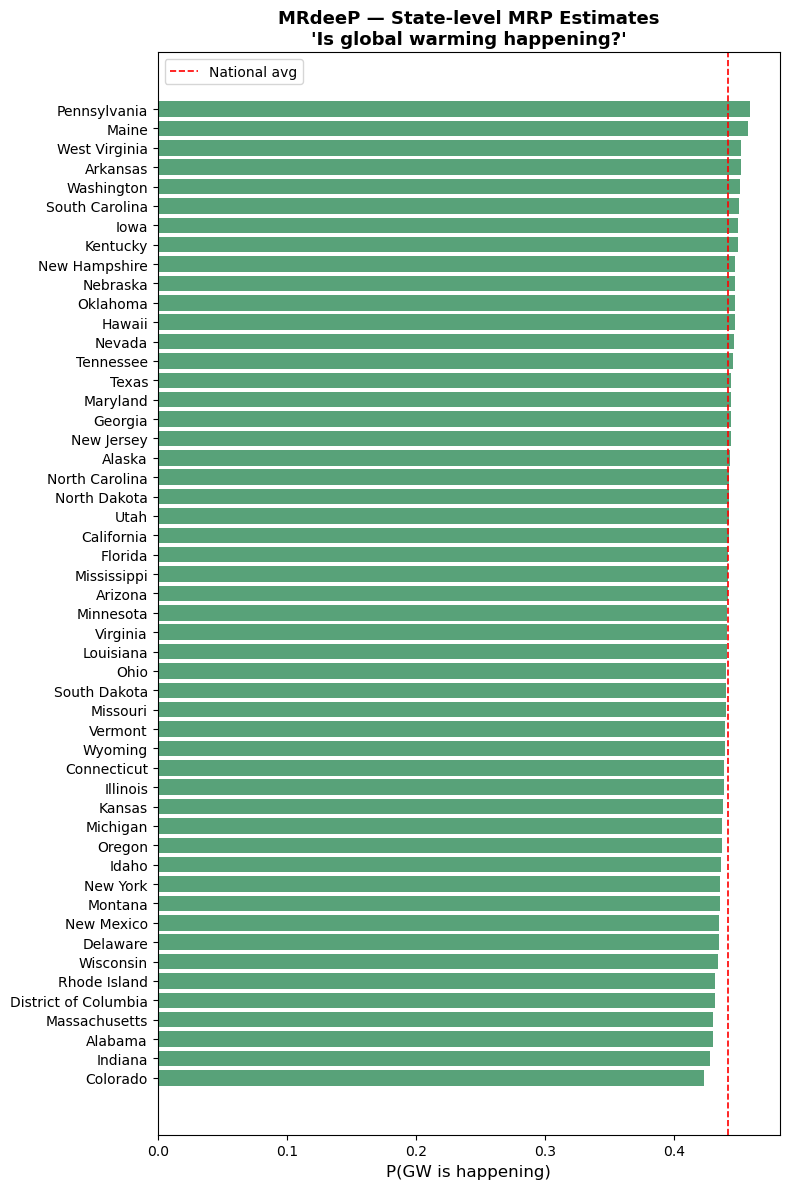

In [29]:
fig, ax = plt.subplots(figsize=(8, 12))
plot_df = result.sort_values("happening_estimate")
ax.barh(plot_df["state_name"], plot_df["happening_estimate"], color="seagreen", alpha=0.8)
ax.axvline(result["happening_estimate"].mean(), color="red",
           linestyle="--", linewidth=1.2, label="National avg")
ax.set_xlabel("P(GW is happening)", fontsize=12)
ax.set_title("MRdeeP — State-level MRP Estimates\n'Is global warming happening?'",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 7. Save results

In [30]:
OUT = "/Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/outputs/estimates/mrdeep_state_estimates.csv"
result[["state_fips", "state_name", "happening_estimate"]].rename(columns={"happening_estimate":"estimate"}).to_csv(OUT, index=False)
print(f"Saved → {OUT}")
print(result[["state_fips", "state_name", "happening_estimate"]].to_string(index=False))

Saved → /Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/outputs/estimates/mrdeep_state_estimates.csv
state_fips           state_name  happening_estimate
        42         Pennsylvania            0.458929
        23                Maine            0.457469
        54        West Virginia            0.451789
        05             Arkansas            0.451677
        53           Washington            0.450957
        45       South Carolina            0.450466
        19                 Iowa            0.449530
        21             Kentucky            0.449190
        33        New Hampshire            0.447293
        31             Nebraska            0.447279
        40             Oklahoma            0.447063
        15               Hawaii            0.446680
        32               Nevada            0.446039
        47            Tennessee            0.445167
        48                Texas            0.444301
        24             Maryland            0.444182
      